# 07. CZ GRAPE end-to-end validation — descent and best-protocol waveforms

Replay-only visualization of `results/cz_grape_e2e/validation.json` (schema 2),
produced by `scripts/cz_grape_e2e_validation.py` on the two-atom `01r`
finite-blockade model (ARC 70S, 4 µm chain, $V_{rr}/2\pi \approx 210.6$ MHz,
$T = 2\,\mu$s, notebook-06 17-coordinate spline basis). This notebook loads the
JSON artifact and draws figures — no ARC, optimizer, or ODE work.

- **Figure 1**: the composite objective
  $J = L_{\rm mean} + 0.6\,S_{\rm cz} + R$ descending over accepted L-BFGS-B
  iterations for all starts (qoc GRAPE discrete-adjoint gradients), with each
  start's *independent* `exact_ode` infidelity $1-F_{\rm avg}$ marked at the
  end, and the final-loss distribution over starts.
- **Figure 2**: the best start's physical waveforms $A(t)$ and $\phi(t)$,
  reconstructed from the 17 saved spline coordinates.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython import get_ipython
from IPython.display import display
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import BSpline

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)

# Embed figures as inline PNGs under a Jupyter kernel (a no-op in a plain
# interpreter); keeps this notebook pure-Python source with no %magic.
_ipython = get_ipython()
if _ipython is not None:
    from IPython.core.pylabtools import select_figure_formats

    select_figure_formats(_ipython, {"png"})

TWOPI = 2.0 * np.pi
MHz = TWOPI * 1e6

payload = json.loads((ROOT / "results" / "cz_grape_e2e" / "validation.json").read_text())
assert payload["schema_version"] == 2, payload["schema_version"]
config = payload["config"]
starts = payload["multistart"]["starts"]
summary = payload["multistart"]["summary"]
best = payload["best"]
acceptance = payload["acceptance"]

print(f"model: V_rr/2pi = {config['V_RR_rad_s'] / MHz:.3f} MHz, "
      f"T = {config['duration_s'] / 1e-6:.2f} us, "
      f"N_search = {config['n_search_slices']}")
print(f"starts: {summary['n_starts']}, feasible {summary['feasibility_rate']:.0%}, "
      f"formally converged {summary['convergence_rate']:.0%}")
print(f"exact 1-F_avg: median {summary['final_exact_infidelity_median']:.3e}, "
      f"best {acceptance['claimed_infidelity']:.3e} ('{best['name']}')")
print(f"all validation checks passed: {acceptance['all_passed']}")


model: V_rr/2pi = 210.626 MHz, T = 2.00 us, N_search = 2048
starts: 8, feasible 100%, formally converged 25%
exact 1-F_avg: median 3.103e-07, best 8.214e-08 ('random_06')
all validation checks passed: True


## 1. GRAPE descent: composite objective over accepted iterations

Entry 0 is the seed evaluation; every later point is one accepted L-BFGS-B
iteration on the analytic discrete-adjoint gradient (line-search evaluations
are not iterations). Solid lines are the three analytic seeds, dashed lines
the five random starts. The marker ending each curve is that start's
**independent** `exact_ode` infidelity $1-F_{\rm avg}$ (filled = feasible) —
the acceptance number, which GRAPE's own slice propagation never decides.
$J$ flattens on the fluence floor $R \sim 10^{-5}$ while the physics part
keeps falling, so the end-of-curve $J$ sits above the exact $1-F_{\rm avg}$.

The right panel shows the final-loss distribution over all starts (not just
the best): final composite $J$ (squares) and exact $1-F_{\rm avg}$ (circles),
sorted by the latter.


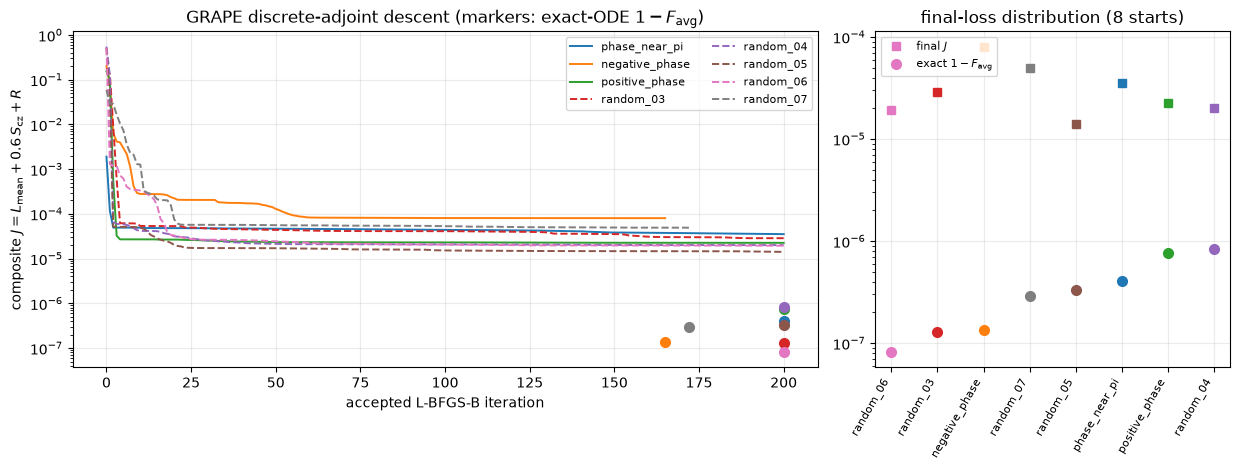

In [2]:
fig, (ax_j, ax_dist) = plt.subplots(
    1, 2, figsize=(12.5, 4.8), width_ratios=[2.1, 1.0])
cmap = plt.get_cmap("tab10")

for index, start in enumerate(starts):
    J = np.array([entry["J"] for entry in start["history"]])
    color = cmap(index % 10)
    style = "-" if start["kind"] == "analytic_seed" else "--"
    ax_j.semilogy(np.arange(J.size), J, style, color=color, lw=1.4,
                  label=start["name"])
    infidelity = start["exact_metrics"]["infidelity"]
    ax_j.semilogy([J.size - 1], [infidelity], "o", color=color, ms=7,
                  mfc=(color if start["feasible"] else "none"), zorder=5)

ax_j.set_xlabel("accepted L-BFGS-B iteration")
ax_j.set_ylabel(r"composite $J = L_{\rm mean} + 0.6\,S_{\rm cz} + R$")
ax_j.set_title(r"GRAPE discrete-adjoint descent (markers: exact-ODE $1-F_{\rm avg}$)")
ax_j.grid(alpha=0.25)
ax_j.legend(fontsize=8, ncols=2)

order = np.argsort([s["exact_metrics"]["infidelity"] for s in starts])
for rank, index in enumerate(order):
    start = starts[index]
    color = cmap(index % 10)
    ax_dist.semilogy([rank], [start["search_metrics"]["J"]], "s", color=color,
                     ms=6, label=("final $J$" if rank == 0 else None))
    ax_dist.semilogy([rank], [start["exact_metrics"]["infidelity"]], "o",
                     color=color, ms=7,
                     mfc=(color if start["feasible"] else "none"),
                     label=(r"exact $1-F_{\rm avg}$" if rank == 0 else None))
ax_dist.set_xticks(range(len(starts)))
ax_dist.set_xticklabels([starts[i]["name"] for i in order],
                        rotation=60, ha="right", fontsize=8)
ax_dist.set_title(f"final-loss distribution ({len(starts)} starts)")
ax_dist.grid(alpha=0.25)
ax_dist.legend(fontsize=8, loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)


## 2. Best protocol: $A(t)$ and $\phi(t)$

The best start (lowest independent exact-ODE infidelity) is reconstructed from
its 17 saved spline coordinates exactly as the physical protocol builds it:
$A(s) = A_{\max} E(s) \sum_k p_k B_k(s)$ with the 15% quintic envelope $E$;
$\chi(s)/\chi_{\max} = (x+v)/(1+xv)$ with $x = -\eta\cos 2\pi s$,
$v = \tanh(E \sum_k d_k B_k)$; and $\phi(t) = \int_0^t \chi\,dt'$. The
`exact_ode` drive that produced the quoted acceptance metrics is
$H_{r1}(t) = \tfrac{A(t)}{2} e^{-i\phi(t)}$.


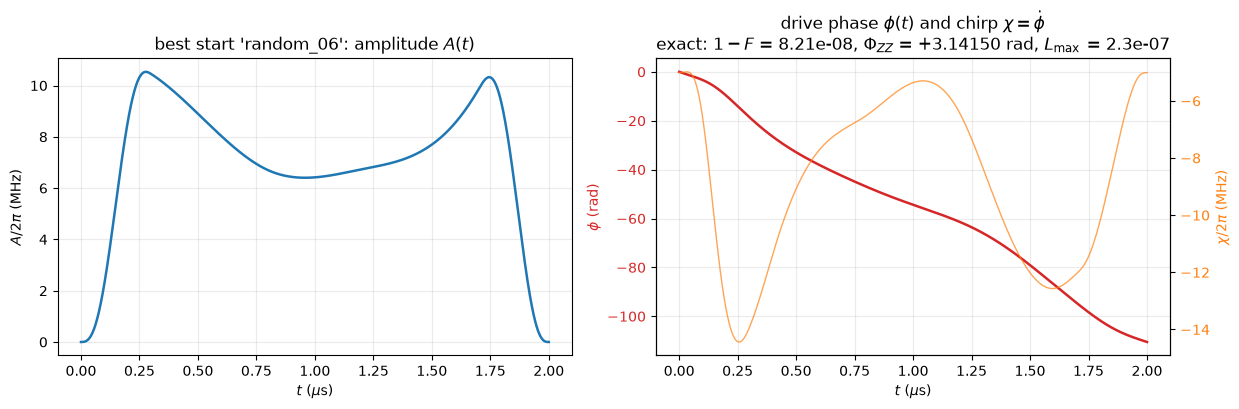

In [3]:
theta = np.asarray(best["theta"], dtype=float)
n_coeffs = int(config["basis_n_coeffs"])
degree = int(config["basis_degree"])
a_max = float(config["amplitude_max_rad_s"])
chi_max = float(config["chirp_max_rad_s"])
duration_s = float(config["duration_s"])

inner = np.linspace(0.0, 1.0, n_coeffs - degree + 1)[1:-1]
knots = np.r_[np.zeros(degree + 1), inner, np.ones(degree + 1)]
spline = BSpline(knots, np.eye(n_coeffs), degree, extrapolate=False)

t = np.linspace(0.0, duration_s, 2001)
s = t / duration_s
B = np.asarray(spline(s))

envelope = np.ones_like(s)
mask = s < 0.15
xx = s[mask] / 0.15
envelope[mask] = 10 * xx**3 - 15 * xx**4 + 6 * xx**5
mask = s > 0.85
xx = (1.0 - s[mask]) / 0.15
envelope[mask] = 10 * xx**3 - 15 * xx**4 + 6 * xx**5

p = theta[:n_coeffs]
d = theta[n_coeffs : 2 * n_coeffs]
eta = theta[-1]
amplitude = a_max * envelope * (B @ p)
x = -eta * np.cos(TWOPI * s)
v = np.tanh(envelope * (B @ d))
chirp = chi_max * (x + v) / (1.0 + x * v)
phase = np.r_[0.0, cumulative_trapezoid(chirp, t)]

exact = best["exact_metrics"]
fig, (ax_a, ax_phi) = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax_a.plot(t / 1e-6, amplitude / MHz, color="tab:blue", lw=1.8)
ax_a.set_xlabel(r"$t$ ($\mu$s)")
ax_a.set_ylabel(r"$A/2\pi$ (MHz)")
ax_a.set_title(f"best start '{best['name']}': amplitude $A(t)$")
ax_a.grid(alpha=0.25)

ax_phi.plot(t / 1e-6, phase, color="tab:red", lw=1.8)
ax_phi.set_xlabel(r"$t$ ($\mu$s)")
ax_phi.set_ylabel(r"$\phi$ (rad)", color="tab:red")
ax_phi.tick_params(axis="y", labelcolor="tab:red")
ax_chi = ax_phi.twinx()
ax_chi.plot(t / 1e-6, chirp / MHz, color="tab:orange", lw=1.0, alpha=0.7)
ax_chi.set_ylabel(r"$\chi/2\pi$ (MHz)", color="tab:orange")
ax_chi.tick_params(axis="y", labelcolor="tab:orange")
ax_phi.set_title(
    r"drive phase $\phi(t)$ and chirp $\chi = \dot\phi$"
    "\n"
    f"exact: $1-F$ = {exact['infidelity']:.2e}, "
    f"$\Phi_{{ZZ}}$ = {exact['Phi_ZZ']:+.5f} rad, "
    f"$L_{{\max}}$ = {exact['basis_leakage_max']:.1e}")
ax_phi.grid(alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)
